<center><img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_1/blob/main/picsForSession/logoHeader.png?raw=true" width="800"></center> 

<a target="_blank" href="https://colab.research.google.com/github/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_1/blob/main/sesion_1.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<div class="alert alert-info" role="alert">
    
## Data para la sesión

Para esta sesión, los datos puedes descargarlos en _tu_ carpeta **data** desde este **[enlace](https://drive.google.com/drive/folders/1moxcN2MaYeyjPA1mVjCaAw19JAQsoXdH?usp=sharing)**, el acceso es con la cuenta _@pucp.edu.pe_.
</div>

# Práctica 1 – Introducción al uso de los Programas para Redes


<img align="right" width="500" height="100" src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_1/blob/main/picsForSession/logosNetSW.png?raw=true">

Para trabajar con grafos (redes) hay una serie de programas que podemos utilizar. La gran diferencia radica en el tamaño del archivo que pueden manejar (complejidad de la red), en el costo del programa, la cantidad y actualización de funciones (algoritmos) implementados, y en si requieren o no programación.



## **ESTRUCTURA DE DATOS**

Veamos la imagen de un grafo en [wikipedia](https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)):

<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_1/raw/main/picsForSession/grafo1.png"/>

De aquí notamos dos componentes básicos: 
* los nodos (_vertex_): `6`,`4`,`5`,`1`,`2`,`3`
* los enlaces (_edges_): `6-4`,`4-5`,`4-3`,`5-2`,`5-1`,`2-3`,`2-1`

Los nodos y enlaces podemos representados en una matriz, donde una celda tenga una marca (`1`) que indique si hay enlace entre los nodos. La gráfica debajo muestra esa matriz:

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/redBasica_adjacency.jpg"/>



Otra manera sería escribir en dos columnas el origen y destino, es decir, los dos nodos que estén conectados por un enlace. La imagen que sigue representa ello:

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/redBasica_edgelist.jpg"/>



Los enlaces mostrados no tienen direccionalidad (flechas), pero pueden tenerla cuando queramos tener un grafo dirigido. Las redes son grafos, pero "red" es una palabra más familiar que usaremos en nuestras sesiones. Las estructuras de matriz o lista de vertices  son compatibles en general, pero el _edgelist_, aun siendo más eficiente, suele no mostrar los nodos de la población bajo estudio que no tenga conexiones con otro nodo (_isolates_).

> ¿Cómo podemos crear esta red en la computadora? 
Redes pequeñas de este tipo pueden crearse manualmente usando, por ejemplo, Python.

In [4]:
import networkx as nx

red1 = nx.Graph()
red1.add_edges_from([(6,4),(4,5),(4,3),(5,2),(5,1),(2,3),(2,1)])

In [5]:
red1.nodes()

NodeView((6, 4, 5, 3, 2, 1))

In [6]:
red1.edges()

EdgeView([(6, 4), (4, 5), (4, 3), (5, 2), (5, 1), (3, 2), (2, 1)])

La creación manual no es comun en estos día. Generalmente necesitamos preparar datos en archivos que luego sean leidos por otro software o librería especializada. Hay que saber elegir la estructura y la herramienta apropiada para crear una red. Por ejemplo, en [esta hoja de calculo](https://docs.google.com/spreadsheets/u/6/d/e/2PACX-1vReqFHgPvGpZiSozcooJkZOH7kOCvtpgtq0fvuIehQ6MfqM-To93umwRY0pJBZzoCetj_ptmLCpNnGv/pubhtml) podemos ver los datos que utilizó Adolfo Figueroa en su [artículo](https://doi.org/10.1016/j.qref.2006.12.016) "_Competition and circulation of economic elites: Theory and application to the case of Peru_" del 2007, en dos formatos, la matriz de adyacencia (**adjancency matrix**) y la lista de enlaces (**edgelist**). La matriz de adyacencia tiene esta apariencia:


<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/red_figue_adj.jpg"/>


# LECTURA DE DATOS

## Usando NETWORKX

_Networkx_ es una librería de Python, un poderoso lenguaje de programación usado por cientistas de datos. Por ello podría instalar Python primero en su computadora (se recomienda [ANACONDA](https://www.anaconda.com/download)). Ello no es necesario si desea usar la versión de Python que ofrece GOOGLE, [Colab](https://colab.research.google.com/).

Si ya está en COLAB, preparese para leer los datos. La tabla antes mostrada, ya almacenada en Google Drive, puede ser utilizada directamente en Python (sea Anaconda o Colab) si contamos con el link:

* Paso 1: _Compartir_ y _Publicar_ tabla en la web:
  
<img src="picsForSession/Drive_step1.jpg" width="300"/>

* Paso 2: Obtener el link

<img src="picsForSession/Drive_step2.jpg" width="300"/>

La <ins>primera vez</ins> que haga el paso 2, debe presionar la opción "_Publicar_" (aqui ya aparece como _"Publicado"_)

A continuación, si está usando Python, puede guardar el link en Python de manera sencilla:

In [7]:
# link a google sheets entre "comillas" 
LinkToGoogle="https://docs.google.com/spreadsheets/d/e/2PACX-1vReqFHgPvGpZiSozcooJkZOH7kOCvtpgtq0fvuIehQ6MfqM-To93umwRY0pJBZzoCetj_ptmLCpNnGv/pub?output=xlsx"


Leamos la matriz de adyacencia, para lo cual primero leemos la tabla usando el link en con la libreria _pandas_:

In [8]:
# leyendo matriz de adyacencia

import pandas as pd

adjacency=pd.read_excel(LinkToGoogle, # link a la tabla
                        index_col=0,  # la columna '0' guarda los nombres
                        sheet_name='adjacency') # la tabla tiene este nombre

El objeto **adjancency** guarda la tabla. Ahora usamos __from_pandas_adjacency()__ de la librería **networkx**, y se crea la red:

In [9]:
# crear red
eliteFromAdjacency=nx.from_pandas_adjacency(adjacency)

La red ya está creada, veamos:

In [10]:
# nodos de la red
eliteFromAdjacency.nodes()

NodeView(('Romero', 'Graña', 'Miro Quesada', 'Moreyra', 'Fort', 'De La Puente', 'Wiese', 'Onrubia', 'Brescia', 'Nicolini', 'Montero', 'Picaso', 'Bentin', 'Benavides', 'Bustamante', 'Woodman Pollit', 'Raffo', 'Piazza', 'Berckemeyer', 'Llosa Barber', 'Beoutis Ledesma', 'Rizo Patron', 'Montori', 'Sotomayor', 'Cilloniz', 'Ferreyros', 'Michell', 'Wong Lu', 'Batievsky Spack', 'Matos Escalada', 'Galsky', 'Lucioni', 'Rodriguez Rodríguez', 'Custer', 'Ikeda', 'Cogorno', 'Arias Davila'))

In [11]:
# enlaces de la red
eliteFromAdjacency.edges()

EdgeView([('Romero', 'Graña'), ('Romero', 'Miro Quesada'), ('Romero', 'Moreyra'), ('Romero', 'Fort'), ('Romero', 'De La Puente'), ('Romero', 'Onrubia'), ('Romero', 'Brescia'), ('Romero', 'Nicolini'), ('Romero', 'Bentin'), ('Romero', 'Benavides'), ('Romero', 'Bustamante'), ('Romero', 'Woodman Pollit'), ('Romero', 'Raffo'), ('Romero', 'Piazza'), ('Romero', 'Berckemeyer'), ('Romero', 'Llosa Barber'), ('Romero', 'Rizo Patron'), ('Romero', 'Montori'), ('Graña', 'Miro Quesada'), ('Graña', 'Fort'), ('Graña', 'De La Puente'), ('Graña', 'Wiese'), ('Graña', 'Montero'), ('Graña', 'Benavides'), ('Graña', 'Bustamante'), ('Graña', 'Piazza'), ('Graña', 'Beoutis Ledesma'), ('Graña', 'Michell'), ('Miro Quesada', 'Fort'), ('Miro Quesada', 'De La Puente'), ('Miro Quesada', 'Wiese'), ('Miro Quesada', 'Montero'), ('Miro Quesada', 'Benavides'), ('Miro Quesada', 'Bustamante'), ('Miro Quesada', 'Piazza'), ('Miro Quesada', 'Beoutis Ledesma'), ('Miro Quesada', 'Michell'), ('Moreyra', 'Fort'), ('Moreyra', 'De La

Si quisieramos usar el _edgelist_, necesitamos:

In [12]:
edgeList=pd.read_excel(LinkToGoogle,
                        sheet_name='edgelist') # la tabla tiene este nombre

edgeList
# crear red
eliteFromEdgelist=nx.from_pandas_edgelist(edgeList,edge_attr=True)

Veamos la diferencia eentre ambas redes:

* Cantidad de Nodos:

In [13]:
# 'len()' se usa para contar elementos
eliteFromAdjacency.number_of_nodes(), eliteFromEdgelist.number_of_nodes()

(37, 31)

* Cantidad de enlaces:

In [14]:
eliteFromAdjacency.number_of_edges(), eliteFromEdgelist.number_of_edges()

(135, 135)

* Las **islas** del _edgelist_:

In [15]:
list(nx.isolates(eliteFromEdgelist))

[]

* Las islas del _adjacency_:

In [16]:
list(nx.isolates(eliteFromAdjacency))

['Lucioni',
 'Rodriguez Rodríguez',
 'Custer',
 'Ikeda',
 'Cogorno',
 'Arias Davila']

La red **eliteFromEdgelist** puede completarse:

In [17]:
eliteFromEdgelist.add_nodes_from(['Lucioni', 'Rodriguez Rodríguez', 'Custer', 'Ikeda', 'Cogorno', 'Arias Davila'])

Ahora tiene los mismos nodos:

In [18]:
eliteFromEdgelist.number_of_nodes()

37

Y claro, sus islas:

In [19]:
list(nx.isolates(eliteFromEdgelist))

['Lucioni',
 'Rodriguez Rodríguez',
 'Custer',
 'Ikeda',
 'Cogorno',
 'Arias Davila']

### Exportación

Las redes creadas con Networkx pueden exportarse en diferentes formatos, que serán útiles en otros programas. Aquí grabaremos en el formato GML y GRAPHML:

In [20]:
import os # para usar funciones de directorio

filename1='eliteFromAdjacency.gml' # nombre incluye 'donde'
filename2='eliteFromAdjacency.graphml'

# guardando:
nx.write_gml(eliteFromAdjacency,filename1)

nx.write_graphml(eliteFromAdjacency,filename2)


# VISUALIZACION DE REDES

Es muy común producir gráficos de redes. La gráficas, si son bien hechas, pueden resaltar algunas propiedades de la red. No siempre es posible lograrlo cuando la red es muy grande y no muestra una estructura clara.

## Usando NETWORKX

Tenemos activa la red _eliteFromAdjacency_. Visualizarla con Networkx es muy sencillo:


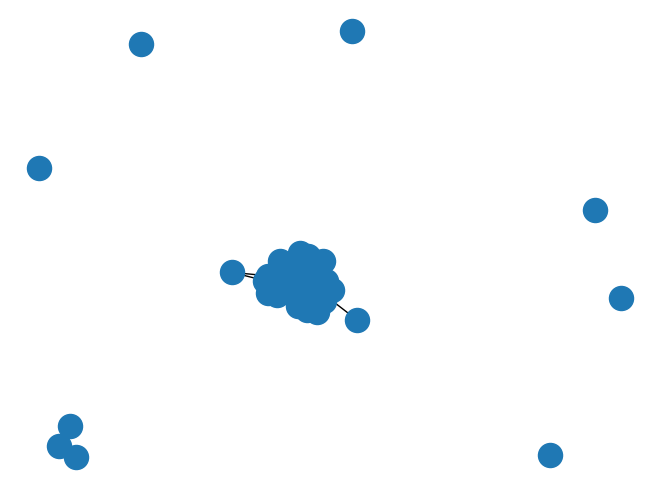

In [21]:
nx.draw(eliteFromAdjacency)

La ubicacion de los nodos sigue por lo general algun algoritmo, este es otro:

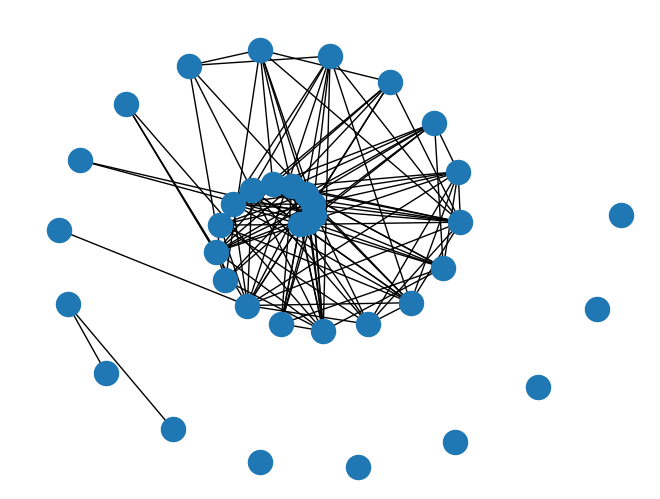

In [22]:
pos = nx.spiral_layout(eliteFromAdjacency) #algoritmo spiral
nx.draw(eliteFromAdjacency, pos=pos)

Hay muchos _layouts_ disponibles, los de Networkx puedes revisarlos [aquí](https://networkx.org/documentation/stable/reference/drawing.html#).

## Usando GEPHI

Gephi es un software de visualización y exploración de redes, de código abierto y gratuito. El Gephi debe instalarse en la computadora directamente desde su [página web](https://gephi.org/users/download/). 

Hasta aquí tenemos varios archivos:

* Un excel con la matriz de adyacencia y el edgelist.
* Un GML con la red ya creada en Python.
* Un GRAPHML con la red ya creada en Python.

Veamos como abrir la matriz de adyacencia en Gephi:

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_excel_adj1.jpg"/>


<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_excel_adj2.jpg"/>


<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_excel_adj3.jpg"/>

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_excel_adj4.jpg"/>

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_excel_adj5.jpg"/>



<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_excel_adj6.jpg"/>




Usemos el GRAPHML, obteniendo esto (¿salieron los nombres?):

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_graphml1.jpg" width="300"/>





Usemos el GRAPHML, obteniendo esto (¿salieron los nombres?):

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_graphml2.jpg" width="600"/>





Usemos el GRAPHML, obteniendo esto (¿salieron los nombres?):

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_graphml3.jpg" width="600"/>





Usemos el GRAPHML, obteniendo esto (¿salieron los nombres?):

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_graphml4.jpg" width="600"/>





Usemos el GRAPHML, obteniendo esto (¿salieron los nombres?):

<img src="https://github.com/maestriaInnovacion-magallanes-redes/creacion_carga/raw/main/picsForSession/gephi_node_edges_options.jpg" width="600"/>





Usemos el GRAPHML, obteniendo esto (¿salieron los nombres?):

<img src="picsForSession/readGRAPHML.png" width="900"/>


<div class="alert-success">

## Ejercicio 3

Abra los demás archivos disponibles, menos los de UCINET.

**¿Qué resultado obtiene?**

</div>

<div class="alert-success">

## Ejercicio 4

Si tiene una red con los nombres en los nodos, descarguela como un archivo gráfico (PDF,PNG, etc.).
En el menú principal, al seleccionar FILE use la opcion EXPORT para grabar la imagen vista.
**¿Obtienes el resultado correcto?**

</div>